# Huấn luyện mô hình Support Vector Machine (SVM)

Dataset: `Leads_Selected_Train.csv` và `Leads_Selected_Test.csv`
- Sử dụng GridSearchCV để tìm tham số tối ưu (kernel, C, gamma).
- Đánh giá bằng Accuracy, Precision, Recall, F1.
- Vẽ và lưu Confusion Matrix, ROC-AUC Curve.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay
)

os.makedirs('results_img', exist_ok=True)

sns.set_theme(style='whitegrid')

## 1. Đọc dữ liệu

In [12]:
df_train = pd.read_csv('Leads_Selected_Train.csv')
df_test = pd.read_csv('Leads_Selected_Test.csv')

X_train = df_train.drop(columns=['Converted'])
y_train = df_train['Converted']

X_test = df_test.drop(columns=['Converted'])
y_test = df_test['Converted']

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

## 2. Tìm kiếm tham số (GridSearchCV)

In [13]:
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf'] 
}

# probability=True để có thể vẽ ROC-AUC hiệu quả
svc = SVC(random_state=42, probability=True,class_weight='balanced')

grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"\nTham số tốt nhất: {grid_search.best_params_}")
print(f"F1 Score tốt nhất (Cross-validation): {grid_search.best_score_:.4f}")

# Lưu mô hình tốt nhất
best_svc = grid_search.best_estimator_
joblib.dump(best_svc, 'best_model_svm.pkl')
print("Đã lưu mô hình tối ưu thành file 'best_model_svm.pkl'")

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Tham số tốt nhất: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
F1 Score tốt nhất (Cross-validation): 0.7776
Đã lưu mô hình tối ưu thành file 'best_model_svm.pkl'


## 3. Đánh giá trên tập Test

In [14]:
y_pred = best_svc.predict(X_test)
y_pred_proba = best_svc.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("=== Kết quả Đánh giá SVM trên Test Set ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

=== Kết quả Đánh giá SVM trên Test Set ===
Accuracy  : 0.8134
Precision : 0.7320
Recall    : 0.8256
F1 Score  : 0.7760
ROC-AUC   : 0.8768


## 4. Trực quan hóa (Confusion Matrix & ROC Curve)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


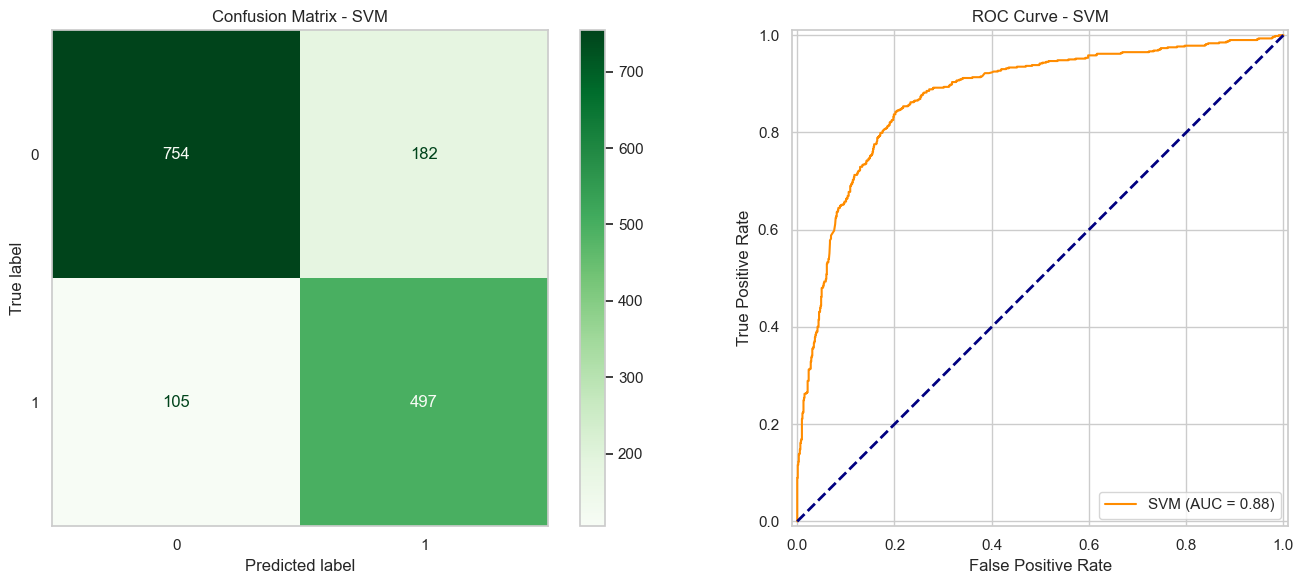

Đã lưu biểu đồ thành 'results_img/SVM_Evaluation.png'


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_svc.classes_)
disp.plot(ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title('Confusion Matrix - SVM')
axes[0].grid(False)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name='SVM')
roc_display.plot(ax=axes[1], color='darkorange')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('ROC Curve - SVM')

plt.tight_layout()
plt.savefig('results_img/SVM_Evaluation.png', dpi=300)
plt.show()

print("Đã lưu biểu đồ thành 'results_img/SVM_Evaluation.png'")